# J–T phase diagrams

Run the same model as `simulation.ipynb` while varying coupling $J$, noise temperature $T$, and the number of informed fish. Use the same fixed escape and refractory durations, initialization, and 200-step update loop.

For each trial, let $s$ be the **largest fraction escaping simultaneously** during the 20 steps after stimulus onset. Plot:

- **Cascade probability:** the fraction of trials with $s\geq0.8$.
- **Cascade size:** the mean peak number escaping, $N\langle s\rangle$, including unsuccessful trials.
- **Susceptibility:** variation between trials, $\chi=N\operatorname{Var}(s)$, using the sample variance.
- **Information response:** $\Delta P=P(\mathrm{cascade}\mid n)-P(\mathrm{cascade}\mid0)$ at the same $J,T$.

Zero informed fish gives a noise-only control. These are short-response measurements, not equilibrium susceptibilities. Start with the small grid below, then increase `n_trials` or add grid points when needed. Use positive temperatures and at least two trials. Run cells in order.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from agent import Agent
from stimulus import square_wave


In [23]:
# Simulation parameters
n_fish = 20
total_timesteps = 100
threshold = 0.5
random_seed = 2026
escape_duration = 5
refractory_duration = 10

# Stimulus and response window
stimulus_start = 10
stimulus_strength = 1.0
stimulus_duration = 5
response_steps = 20

# Parameter sweep ranges for phase diagram
J_values = np.linspace(0, 3, 15)
T_values = np.linspace(0.01, 0.2, 15)
informed_counts = [0, 1, 3, 5, 10, 20]
n_trials = 20
cascade_fraction = 0.8


## One trial

This is the same sequential loop as in `simulation.ipynb`, wrapped in a function. It returns the escape fraction at each step. Each trial runs all `total_timesteps`; the response window is used only when calculating the outcome measures.

In [24]:
def run_trial(J, T, n_exposed, seed):
    # Initialise n_fish number of agents
    rng = np.random.default_rng(seed)
    agents = np.array([Agent() for _ in range(n_fish)])
    for agent in agents:
        agent.spin = 0

    # Select a fixed subset that receives the direct stimulus
    exposed = np.zeros(n_fish, dtype=bool)
    exposed[rng.choice(n_fish, size=n_exposed, replace=False)] = True

    # Create stimulus and state history arrays
    time = np.arange(total_timesteps)
    stimulus = square_wave(time - stimulus_start, stimulus_strength, stimulus_duration)
    state_history = np.empty((n_fish, len(time)), dtype=np.int8)
    state_history[:, 0] = [agent.spin for agent in agents]

    # Run the simulation
    for t in range(total_timesteps):
        already_escaping = np.array([agent.spin == 1 for agent in agents])
        already_refractory = np.array([agent.refractory_timer > 0 for agent in agents])
        eligible = ~(already_escaping | already_refractory)
        active_count = int(already_escaping.sum())

        # Random sequential updates: the field changes after each new escape
        for fish in rng.permutation(np.flatnonzero(eligible)):
            activity = active_count / n_fish

            # Only exposed fish receive the external threat pulse
            direct_stimulus = stimulus[t] if exposed[fish] else 0.0
            field = direct_stimulus + J * activity - threshold
        
            probability = 1 / (1 + np.exp(-field / T))
            if rng.random() < probability:
                agents[fish].spin = 1
                agents[fish].recovery_timer = escape_duration
                active_count += 1

        # Advance existing refractory timers before assigning newly recovered fish
        for fish in np.flatnonzero(already_refractory):
            agents[fish].refractory_timer -= 1

        for fish in np.flatnonzero(already_escaping):
            agents[fish].recovery_timer -= 1
            if agents[fish].recovery_timer == 0:
                agents[fish].spin = 0
                agents[fish].refractory_timer = refractory_duration

        state_history[:, t] = [agent.spin for agent in agents]

    return state_history.mean(axis=0)


## Repeat trials across the grid

Every trial starts with all fish available and gets a fresh random subset of informed fish

In [25]:
rng = np.random.default_rng(random_seed)
shape = (len(informed_counts), len(T_values), len(J_values))
cascade_probability = np.zeros(shape)
cascade_size = np.zeros(shape)

for ni, n_exposed in enumerate(informed_counts):
    for ti, T in enumerate(T_values):
        for ji, J in enumerate(J_values):
            peaks = np.empty(n_trials)
            for trial in range(n_trials):
                seed = rng.integers(0, 2**32)
                activity = run_trial(J, T, n_exposed, seed)
                peaks[trial] = activity[stimulus_start:stimulus_start + response_steps].max()

            cascade_probability[ni, ti, ji] = np.mean(peaks >= cascade_fraction)
            cascade_size[ni, ti, ji] = n_fish * peaks.mean()
    print(f"Finished {n_exposed} informed fish")


Finished 0 informed fish
Finished 1 informed fish
Finished 3 informed fish
Finished 5 informed fish
Finished 10 informed fish
Finished 20 informed fish


## Compare informed counts

Each column has a different informed count; each row shows one outcome. Color scales are shared within each row.

The third row subtracts the zero-informed cascade probability at the same J and T. Positive values show how much direct information increases the response; values near zero mean cascades are about as likely without that information. Negative values are retained. The zero-informed column is exactly zero by construction.

Keep 0 in `informed_counts` to provide the baseline. The desired regime has a high positive difference and a low zero-informed probability in the first row. Noise can still trigger cascades without informed fish; the subtraction measures that background rather than assuming it is absent.


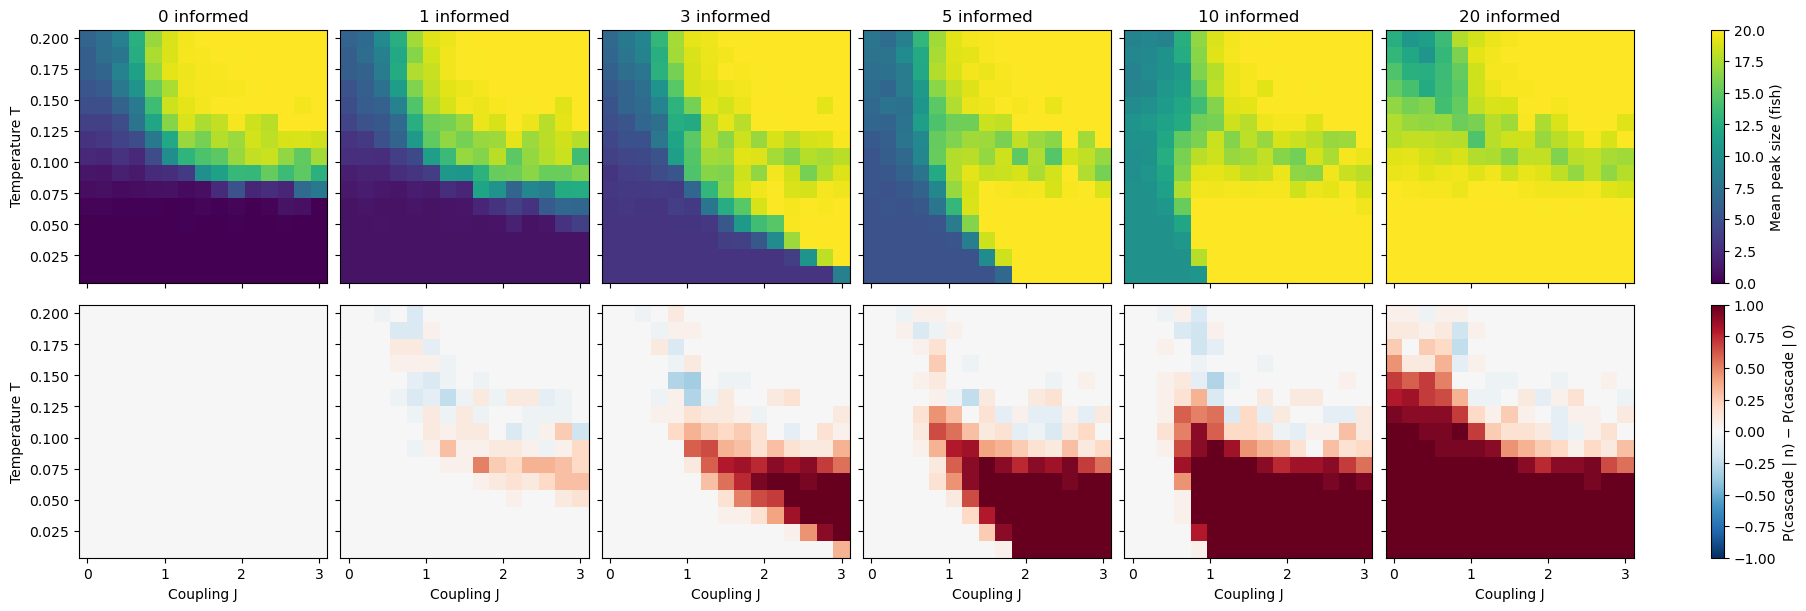

In [31]:
# Subtract the matching zero-informed control for every J and T.
zero_index = list(informed_counts).index(0)
information_response = cascade_probability - cascade_probability[zero_index]

fig, axes = plt.subplots(2, len(informed_counts), figsize=(3 * len(informed_counts), 6), sharex=True, sharey=True, squeeze=False, constrained_layout=True)

outcomes = [(cascade_size, "Mean peak size (fish)", 0, n_fish, "viridis"), (information_response, "P(cascade | n) − P(cascade | 0)", -1, 1, "RdBu_r")]
for row, (values, label, minimum, maximum, cmap) in enumerate(outcomes):
    for ni, count in enumerate(informed_counts):
        ax = axes[row, ni]
        image = ax.pcolormesh(J_values, T_values, values[ni], vmin=minimum, vmax=maximum, cmap=cmap)
        if row == 0:
            ax.set_title(f"{count} informed")
        if row == 1:
            ax.set_xlabel("Coupling J")
        if ni == 0:
            ax.set_ylabel("Temperature T")
    fig.colorbar(image, ax=axes[row].tolist(), label=label)
plt.show()
